# Week 4, Lab 2: LangGraph Orchestration

## What this lab covers

This lab models an application as a LangGraph state machine. It defines state, nodes, edges, and tool execution before adding model calls, persistence through in-memory and SQLite checkpointers, state inspection, and checkpoint replay.

### Four level of abstractions: 
    1. Langchain-core
    2. Langgraph -- (currently exploring this one)
    3. Langchain (create_agent)
    4. DeepAgent

#### Day 01: The building blocks

In [ ]:
# Let's import some libraries
import os
import random
from typing import List, Optional, Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_azure_ai.chat_models import AzureAIOpenAIApiChatModel
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from IPython.display import Markdown, display, Image
import gradio as gr
from azure.identity import AzureCliCredential
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
import json
from langchain_community.tools import TavilySearchResults
from langchain_community.tools import GoogleSerperRun
from langchain_community.utilities import GoogleSerperAPIWrapper
from langgraph.checkpoint.sqlite import SqliteSaver
import urllib3
import requests
import re
import asyncio
import datetime
import win32com.client
import pythoncom
import subprocess
import time

# let's load the environment variables
load_dotenv(override=True)

In [3]:
# Let's see if the API key is working/helping us to call LLM from Azure Foundry
import os
# From OpenAI
AZURE_OPENAI_API_KEY= os.getenv("AZURE_OPENAI_API_KEY")
AZURE_OPENAI_MODEL_DEPLOYMENT = os.getenv("AZURE_OPENAI_DEPLOYMENT")
AZURE_OPENAI_ENDPOINT = os.getenv("AZURE_OPENAI_ENDPOINT")
AZURE_OPENAI_API_VERSION = os.getenv("AZURE_OPENAI_API_VERSION")
AZURE_OPENAI_DEPLOYMENT_GPT_41 = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_41")
AZURE_OPENAI_DEPLOYMENT_GPT_54_mini = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_54_mini")
AZURE_OPENAI_DEPLOYMENT_GPT_55 = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_55")
AZURE_OPENAI_DEPLOYMENT_GPT_4O_mini = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_4O_mini")
if AZURE_OPENAI_API_KEY:
    print("AZURE_OPENAI_API_KEY is available")
else:
    print("AZURE_OPENAI_API_KEY is not available")

# From Anthropic
AZURE_CLAUDE_DEPLOYMENT_OPUS_48=os.getenv("AZURE_CLAUDE_DEPLOYMENT_OPUS_48")
AZURE_CLAUDE_ENDPOINT=os.getenv("AZURE_CLAUDE_ENDPOINT")
AZURE_CLAUDE_API_KEY=os.getenv("AZURE_CLAUDE_API_KEY")
if AZURE_CLAUDE_API_KEY:
    print("AZURE_CLAUDE_API_KEY is avaiable")
else:
    print("AZURE_CLAUDE_API_KEY is not available")

# setting up tavily api key
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
SERP_API_KEY=os.getenv("SERP_API_KEY")
if SERP_API_KEY:
    print("SERP Available")
else:
    print("SERP Not Available")

EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS_TO")
if EMAIL_ADDRESS:
    print("Email address present!")
else:
    print("Email adderess not found!")

AZURE_OPENAI_API_KEY is available
AZURE_CLAUDE_API_KEY is avaiable
SERP Available
Email address present!


In [4]:
# setting up the chat model client
llm_GPT_41  = AzureChatOpenAI(
    azure_endpoint = AZURE_OPENAI_ENDPOINT,
    azure_deployment = AZURE_OPENAI_DEPLOYMENT_GPT_41,
    api_key = AZURE_OPENAI_API_KEY,
    api_version = AZURE_OPENAI_API_VERSION
)
llm_GPT_41

AzureChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15', 'langchain-openai': '1.5.1'}}, profile={'name': 'GPT-4.1', 'release_date': '2025-04-14', 'last_updated': '2025-04-14', 'open_weights': False, 'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000018AD3E3BB80>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000018AD48CF820>, root_client=<openai.lib.azure.AzureOpenAI object at 0

#### State

In [5]:
# let's define a small state which will be update/replaced throughout the chat with llm
class State(TypedDict):
    messages: Annotated[list, add_messages]

#### Five steps to a graph (no LLM)

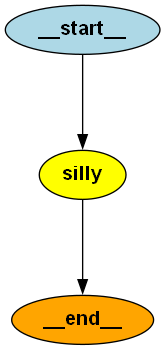

In [6]:
nouns = ["Cabbages", "Unicorns","Toasters","Penguins","Bananas","Eels","Pickles"]
adjectives = ["Outrageous", "smelly", "Pedantic","existential","sparkly","haunted"]

def silly_node(state: State) -> dict:
    sentence = f"{random.choice(nouns)} are {random.choice(adjectives)}"
    return {"messages": [
         {
            "role": "assistant",
            "content": sentence
        }
    ]}

builder = StateGraph(State)
builder.add_node("silly", silly_node)
builder.add_edge(START,"silly")
builder.add_edge("silly", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_png()))



In [7]:
# let's call the graph
result = graph.invoke(
{
    "messages": [
        {
            "role": "user",
            "content": "say something"
        }
    ]
}
)
print(result['messages'][-1].content)

Bananas are Outrageous


Failed to get info from https://apac.api.smith.langchain.com: LangSmithConnectionError('Connection error caused failure to GET /info in LangSmith API. Please confirm your LANGCHAIN_ENDPOINT. SSLError(MaxRetryError("HTTPSConnectionPool(host=\'apac.api.smith.langchain.com\', port=443): Max retries exceeded with url: /info (Caused by SSLError(SSLCertVerificationError(1, \'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1007)\')))"))\nContent-Length: None\nAPI Key: lsv2_********************************************81')
Run compression is not enabled. Please update to the latest version of LangSmith. Falling back to regular multipart ingestion.


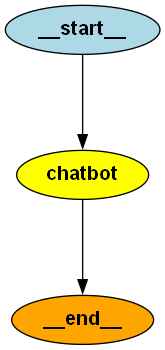

Failed to multipart ingest runs: Connection error caused failure to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your LANGCHAIN_ENDPOINT. SSLError(MaxRetryError("HTTPSConnectionPool(host='apac.api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1007)')))"))
Content-Length: 4640
API Key: lsv2_********************************************81trace=01a05e2a-223e-7d73-9923-b3a088ca707f,id=01a05e2a-223e-7d73-9923-b3a088ca707f; trace=01a05e2a-223e-7d73-9923-b3a088ca707f,id=01a05e2a-2549-7051-98eb-1a97080f58ef


In [8]:
# Now let's try making a graph with a LLM call
# setting up the node
def chatbot_node(state: State) -> dict:
    return {
        "messages": [
            llm_GPT_41.invoke(state['messages'])
        ]
    }
builder = StateGraph(State)
builder.add_node("chatbot", chatbot_node)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_png()))


In [12]:
result = graph.invoke(
    {
        "messages":[
            {
                "role": "user",
                "content": "What is a directed graph, in one sentence?"
            }
        ]
    }
)
print(result['messages'][-1].content)

A directed graph is a set of vertices connected by edges, where each edge has a direction going from one vertex to another.


#### Setting up the tool in the graph as a node 

In [11]:
## setting up Serpapi as websearch tool for LLM

def list_serpapi_results(response: dict, max_results: int | None = None) -> list[dict]:
    """Print and return readable search results from a SerpApi response.

    The returned list contains only the fields normally needed by an agent:
    title, link, displayed_link, snippet, and position.
    """
    if not isinstance(response, dict):
        raise TypeError("response must be the dictionary returned by search_serpapi_debug")

    if response.get("error"):
        print(f"SerpApi error: {response['error']}")
        return []

    organic_results = response.get("organic_results", [])
    if not isinstance(organic_results, list):
        print("No readable organic_results list was found in the API response.")
        return []

    results = []
    print("\n ###########-printing SERP api response-############")
    for result in organic_results[:max_results]:
        if not isinstance(result, dict):
            continue

        item = {
            "position": result.get("position"),
            "title": result.get("title", "Untitled"),
            "link": result.get("link", ""),
            "displayed_link": result.get("displayed_link", ""),
            "snippet": result.get("snippet", ""),
        }
        results.append(item)

        print(f"{item['position']}. {item['title']}")
        print(f"   URL: {item['link']}")
        if item["snippet"]:
            print(f"   {item['snippet']}")
        print()

    if not results:
        print("The API response contains no organic search results.")

    return results

# setting up a google search api tool
@tool
def search_serpapi_tool(query: str) -> list[dict]:
    """Performs a search using SerpApi and prints raw response metadata if JSON parsing fails.
    Then print and return readable search results from a SerpApi response.
    """
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    url = "https://serpapi.com/search"

    params = {"engine": "google", "q": query, "api_key": SERP_API_KEY, "num": 5}

    try:
        response = requests.get(url, params=params, verify=False)

        # 1. Print status code to see what the server actually answered
        print(f"[DEBUG] HTTP Status Code: {response.status_code}")

        # 2. Check if the response header is actually JSON
        content_type = response.headers.get("Content-Type", "")
        print(f"[DEBUG] Content-Type Header: {content_type}")

        # If it's an error page or HTML block, print the snippet to read the error
        if "application/json" not in content_type:
            print("[DEBUG] Received unexpected non-JSON body:")
            print(response.text[:500])  # Prints first 500 characters
            return {}

        return list_serpapi_results(response.json(), max_results=10) # List the results returned by the previous SerpApi call.
        
    except requests.exceptions.RequestException as e:
        print(f"An error occurred during the SerpApi call: {e}")
        return {}



# # --- Usage Example ---
# results = search_serpapi_debug(query="latest advancements in Agentic AI 2026")
# print(results)

## Setting up email sending method/tool 
# define a method/function to send email via Outlook COM
@tool
def send_email_tool( 
    subject: str,
    body: str
    ) -> bool:
    """Send an email using the local Outlook desktop client."""
    # Normalize recipient to a semicolon-separated string (Outlook format)
    recipient = EMAIL_ADDRESS
    recipients = []
    if isinstance(recipient, list):
        recipients = [r.strip() for r in recipient if r.strip()]
    elif isinstance(recipient, str):
        if "," in recipient:
            recipients = [r.strip() for r in recipient.split(",") if r.strip()]
        else:
            recipients = [recipient.strip()]
    
    def validate_email(email: str) -> bool:
        """Validate email format."""
        pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
        return re.match(pattern, email.strip()) is not None

    # Validate all recipients
    invalid_recipients = [r for r in recipients if not validate_email(r)]
    if invalid_recipients:
        print(f"Error: Invalid email format(s): {invalid_recipients}")
        return False
    
    recipient_str = "; ".join(recipients)
    
    if not recipient_str:
        print("Error: No recipients specified. Email not sent.")
        return False

    if body is None:
        body = "Hello there!! "

    print(f"\nSending email to {recipient_str} with subject '{subject}'...")

    # Ensure COM is initialized for the current thread (agent tool calls may run in worker threads).
    pythoncom.CoInitialize()
    try:
        # Connect to Outlook, launch it if not running
        outlook = None
        for attempt in range(5):
            try:
                outlook = win32com.client.Dispatch("Outlook.Application")
                outlook.GetNamespace("MAPI")
                print("Outlook is up & running...")
                break
            except Exception as e:
                if attempt == 0:
                    print("Outlook not running — launching...")
                    for p in [r"C:\Program Files\Microsoft Office\root\Office16\OUTLOOK.EXE",
                              r"C:\Program Files (x86)\Microsoft Office\root\Office16\OUTLOOK.EXE"]:
                        if os.path.exists(p):
                            subprocess.Popen([p])
                            time.sleep(45)
                            break
                    else:
                        print("Error: Outlook executable not found.")
                        return False
                elif attempt < 4:
                    print(f"Outlook connect attempt {attempt + 1}/5 — waiting...")
                    time.sleep(15)
                else:
                    print(f"Error: Outlook connect failed after 5 attempts: {e}")
                    return False

        try:
            mail = outlook.CreateItem(0)
            mail.To = recipient_str
            mail.Subject = subject
            mail.Body = body

            mail.Send()
            print(f"\nEmail sent successfully to '{recipient_str}' with subject '{subject}'.")
            return True

        except Exception as e:
            print(f"Failed to send email: {e}")
            # Print recipient info for debugging
            print(f"Debug - Recipients used: {repr(recipient_str)}")
            print(f"Debug - Recipient type: {type(recipient_str)}")
            return False
    finally:
        try:
            pythoncom.CoUninitialize()
        except Exception:
            pass

## binding the tools with llm
tools = [search_serpapi_tool, send_email_tool]
llm_GPT_41_with_tools = llm_GPT_41.bind_tools(tools)

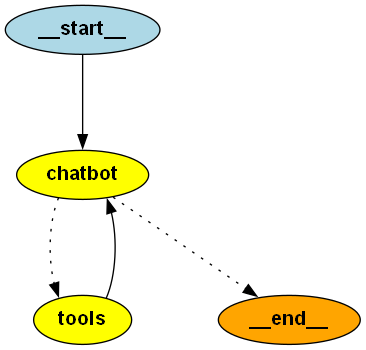

In [11]:
# let's define the graph with nodes, edges, tools, llm
# define state
def chatbot_node(state: State) -> dict:
    return {
        "messages":[
            llm_GPT_41_with_tools.invoke(state['messages'])
        ]
    }

builder = StateGraph(State)
builder.add_node("chatbot", chatbot_node)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_png()))

In [12]:
# let's run the graph
result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "I need to know the current/latest/new ways of making a banoffee pie and send a email to the recepient(Mr. Hardeep) about it."
            }
        ]
    }
)
print(result["messages"][-1].content)

[DEBUG] HTTP Status Code: 200
[DEBUG] Content-Type Header: application/json; charset=utf-8

 ###########-printing SERP api response-############
1. Banoffee Pie Recipe
   URL: https://sallysbakingaddiction.com/banoffee-pie/
   This easy banoffee pie combines a crunchy graham cracker crust, sweet dulce de leche, thick slices of fresh banana, and billowy whipped ...

2. Banoffee Pie Recipe
   URL: https://pinchofyum.com/banoffee-pie
   This banoffee pie recipe features a graham cracker crust, silky toffee filling, sliced bananas, and whipped cream. Make a Graham Cracker Crust. ...

3. 5-Ingredient British Banoffee Pie
   URL: https://www.seriouseats.com/banoffee-pie-recipe-8646124
   This low-effort dessert with gooey dulce de leche, sliced bananas, and whipped cream is a British classic—and ・ 5-Ingredient British Banoffee ...

4. Easy Banoffee Pie
   URL: https://cloudykitchen.com/blog/easy-banoffee-pie/
   My banoffee pie recipe has a brown butter graham cracker base, a layer of banana

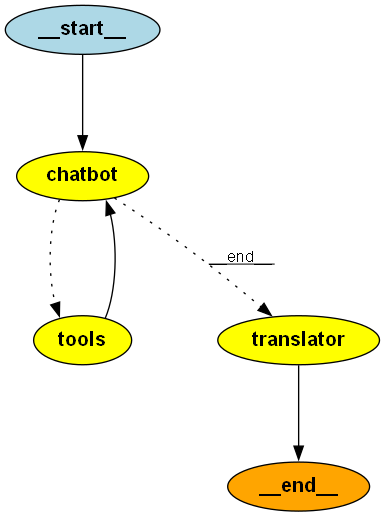

In [12]:
## defining a new state class
class State(TypedDict):
    messages: Annotated[list, add_messages]
    spanish: str

# define a translator node
def translator_node(state: State) -> dict:
    last = state["messages"][-1].content
    prompt = f"Translate this into Spanish, replying with the translation only: \n\n{last}"
    return {
        "spanish": llm_GPT_41.invoke(prompt).content
    }

builder = StateGraph(State)
builder.add_node("chatbot", chatbot_node)
builder.add_node("tools", ToolNode(tools))
builder.add_node("translator", translator_node)
builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition, {"tools": "tools", END:"translator"})
builder.add_edge("tools","chatbot")
builder.add_edge("translator",END)
graph = builder.compile()

display(Image(graph.get_graph().draw_png()))

In [36]:
result = graph.invoke(
    {
        "messages":[
            {
                "role": "user",
                "content": "In one sentence, Tell me a joke about a wife.."
            }
        ]
    }
)

print(result["messages"][-1].content)
print(result["spanish"])

Why did my wife bring a ladder to the bar? Because she heard the drinks were on the house!
¿Por qué mi esposa llevó una escalera al bar? ¡Porque escuchó que las bebidas estaban en la casa!


#### Memory: Why the graph forgets, and how to fix it

In [7]:
# setting up the node
def chatbot_node(state: State) -> dict:
    return {
        "messages": [
            llm_GPT_41.invoke(state['messages'])
        ]
    }

In [13]:
memory = MemorySaver()
builder = StateGraph(State)
builder.add_node("chatbot", chatbot_node)
builder.add_node("tools",ToolNode(tools))
builder.add_node("translator", translator_node)
builder.add_edge(START,"chatbot")
builder.add_edge("translator", END)
builder.add_conditional_edges("chatbot", tools_condition, {"tools": "tools", END: "translator"})
builder.add_edge("tools", "chatbot")
graph = builder.compile(checkpointer = memory)
# graph = builder.compile()

# display(Image(graph.get_graph().draw_png()))

# setting up a thread
config = {"configurable": {
    "thread_id": "conversation-1"
}}

first = graph.invoke(
    {
        "messages": [
            {
                "role": "user", 
                "content": "Hi, my name is Hardeep."
            }
        ]
    }, config
)
print("Results first invoke:", first['messages'][-1].content)
print("In Spanish:", first['spanish'])
second = graph.invoke(
    {
        "messages":[
            {
                "role": "user",
                "content": "What my name is..?"
            }
        ]
    }, config
)
print("\n\n")
print("Results second invoke:", second['messages'][-1].content)
print("In Spanish:", second['spanish'])


Results first invoke: Hello, Hardeep! Nice to meet you. How can I assist you today?
In Spanish: ¡Hola, Hardeep! Encantado de conocerte. ¿Cómo puedo ayudarte hoy?



Results second invoke: Your name is Hardeep.
In Spanish: Tu nombre es Hardeep.


#### Persisting to SQLite

In [14]:
with SqliteSaver.from_conn_string("memory.db") as sql_memory:
    durable_graph = builder.compile(checkpointer = sql_memory)
    # setting up a thread for providing a number for it to give to this thread for tracing in LangSmith
    sql_config = {"configurable": {
        "thread_id": "conversation-2"
    }}
    durable_graph.invoke({
        "messages": [{"role":"user", "content": "My favorite color is ocean-blue..amigo"}]
    }, sql_config)
    reply = durable_graph.invoke({
        "messages": [{"role":"user", "content": "What is my favorite color..amigo"}]
    },sql_config)
    print(reply['messages'][-1].content)
    print(reply['spanish'])


Your favorite color is ocean-blue, amigo!
¡Tu color favorito es azul oceánico, amigo!


#### Looking inside the state, and travelling back in time

In [19]:
snapshot = graph.get_state(config)
messages = snapshot.values["messages"]
print("Messages stored so far:", len(messages))

for message in messages:
    print(message.content)

history = list(graph.get_state_history(config))
print("Number of saved checkpoints:", len(history))


Messages stored so far: 4
Hi, my name is Hardeep.
Hello, Hardeep! Nice to meet you. How can I assist you today?
What my name is..?
Your name is Hardeep.
Number of saved checkpoints: 8


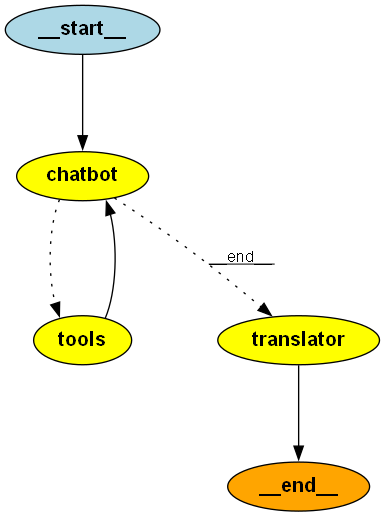

In [29]:
display(Image(graph.get_graph().draw_png()))

In [16]:
config

{'configurable': {'thread_id': 'conversation-1'}}

In [31]:
# print the history
print("Used config:", config)
history = list(graph.get_state_history(config))
print("\nNumber of saved checkpoints:", len(history))
print("\n")
for step in reversed(history):
    md = step.metadata
    queued = ", ".join(next_node.name for next_node in step.tasks) or "(run complete)"
    print(f"step {md['step']:>2} {md['source']:<5}  messages={len(step.values.get('messages',[]))} about to run: {queued}")

Used config: {'configurable': {'thread_id': 'conversation-1'}}

Number of saved checkpoints: 8


step -1 input  messages=0 about to run: __start__
step  0 loop   messages=1 about to run: chatbot
step  1 loop   messages=2 about to run: translator
step  2 loop   messages=2 about to run: (run complete)
step  3 input  messages=2 about to run: __start__
step  4 loop   messages=3 about to run: chatbot
step  5 loop   messages=4 about to run: translator
step  6 loop   messages=4 about to run: (run complete)


#### Time travel: 
##### Take a checkpoint from earlier and resume the graph from that exact moment.

In [33]:
earlier = history[len(history) // 2]
    
print("A checkpoint from earlier held", len(earlier.values["messages"]), "messages")

replay_config = {
    "configurable": {
        "thread_id": "conversation-1", 
        "checkpoint_id": earlier.config['configurable']['checkpoint_id']
    }
}

resumed = graph.invoke(
    {
        "messages":[
            {
                "role": "user",
                "content":"Hey I just wanted to say hi.. and do you remember my name or forgot..?"
            }
        ]
    }, replay_config
)
print("Resumed from the past; the graph now holds", len(resumed['messages']), "messages")

A checkpoint from earlier held 2 messages
Resumed from the past; the graph now holds 4 messages


In [34]:
snapshot = graph.get_state(config)
messages = snapshot.values["messages"]
print("Messages stored so far:", len(messages))

for message in messages:
    print(message.content)

history = list(graph.get_state_history(config))
print("Number of saved checkpoints:", len(history))


Messages stored so far: 4
Hi, my name is Hardeep.
Hello, Hardeep! Nice to meet you. How can I assist you today?
Hey I just wanted to say hi.. and do you remember my name or forgot..?
Hi again, Hardeep! I remember your name—you just told me. If you ever want me to recall things from earlier in our conversation, let me know. How’s your day going?
Number of saved checkpoints: 12
